# 당뇨병 예측 모델 만들어보기

## 0. 계획
|모델\전처리|N/A|Mean|knn|del_insulin
|---|---|---|---|---
|knn|  |  |  |
|Logistic| | | |


In [221]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head())

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


## 1. 0값을 건들지 않고, 만들어보기

In [222]:
#0을 결측치 처리

zero_cols = ["Glucose_Concentration", "BP", "Skin_Thickness", "Serum_Insulin", "BMI"]
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

### 1.A KNN- N/A

In [ ]:
x = df[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
        "Serum_Insulin", "BMI", "Diabetes_Pedigree_Function", "Age"]] #x에 feature 넣기

y = df["Outcome"] #y에 결과 넣기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print(train_target.shape, test_target.shape) #train_target크기, test_target 크기

(614,) (154,)


In [225]:
print(test_target)

44     0
672    0
700    0
630    1
81     0
      ..
32     0
637    0
593    0
425    1
273    0
Name: Outcome, Length: 154, dtype: int64


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)  #실패

ValueError: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

input에 N/A가 포함되니 실행이 안됨. N/A를 다른 값으로 처리해야할듯.

## 2. 전처리 방법. Median

In [227]:
# 중앙값으로 대체
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

### 2.1 KNN-Median

In [228]:
x = df[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
        "Serum_Insulin", "BMI", "Diabetes_Pedigree_Function", "Age"]]

y = df["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [229]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target) #훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8013029315960912
0.6753246753246753


score가 0.67이 나왔다.      
표준화 처리를 안한 것이 생각났다.   

In [230]:
#표준화 처리
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [231]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target) #훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8013029315960912
0.6753246753246753


그래도 동일한 값이다.

다시.

### 2.2 KNN의 이웃수를 변경해보기  

In [232]:
x = df[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
        "Serum_Insulin", "BMI", "Diabetes_Pedigree_Function", "Age"]]

y = df["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [233]:
# K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8420195439739414
0.6818181818181818


In [234]:
print(test_input)

     n_Pregnancies  Glucose_Concentration     BP  Skin_Thickness  \
44               7                  159.0   64.0            29.0   
672             10                   68.0  106.0            23.0   
700              2                  122.0   76.0            27.0   
630              7                  114.0   64.0            29.0   
81               2                   74.0   72.0            29.0   
..             ...                    ...    ...             ...   
32               3                   88.0   58.0            11.0   
637              2                   94.0   76.0            18.0   
593              2                   82.0   52.0            22.0   
425              4                  184.0   78.0            39.0   
273              1                   71.0   78.0            50.0   

     Serum_Insulin   BMI  Diabetes_Pedigree_Function  Age  
44           125.0  27.4                       0.294   40  
672           49.0  35.5                       0.285   47  
700

In [235]:
#표준화 처리
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [236]:
print(test_scaled)

[[ 0.96054099  1.24515673 -0.66367599 ... -0.74014536 -0.55579092
   0.56103382]
 [ 1.86648903 -1.79026591  2.76066903 ...  0.44778472 -0.58306107
   1.15306018]
 [-0.5493724   0.01097389  0.3147083  ...  0.50644793  0.01688223
  -0.6230189 ]
 ...
 [-0.5493724  -1.32327781 -1.64206028 ... -0.57882152  3.70138246
  -0.70759409]
 [ 0.05459296  2.07906404  0.47777235 ...  0.66777177 -0.64669142
  -0.20014293]
 [-0.85135507 -1.69019703  0.47777235 ...  0.11047124 -0.16794879
  -1.04589487]]


In [237]:
# K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
kn.fit(train_scaled, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_scaled, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_scaled, test_target)) # 테스트 세트로 모델 평가

0.8469055374592834
0.7207792207792207


결과적으로      

- 이웃 수가 줄어들면 더 소수를 대상으로 학습하므로 → 더 “민감한” 모델, 과대적합 위험 ↑

- 이웃 수가 많아지면 → 더 “부드러운” 모델, 과소적합 위험 ↑

|n_neighbors|	train score|	test score
|---|---|---
|5(Default)	|0.8013	|0.6753
|3	|0.8469	|0.7208

n의 수를 2와 4로도 해봐야겠다.

In [238]:
# K-최근접 이웃 분류기 훈련하기 n=2
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=2) # 최근접 이웃 3개로
kn.fit(train_scaled, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_scaled, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_scaled, test_target)) # 테스트 세트로 모델 평가

0.8436482084690554
0.7272727272727273


In [239]:
# K-최근접 이웃 분류기 훈련하기 n=4
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=4) # 최근접 이웃 3개로
kn.fit(train_scaled, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_scaled, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_scaled, test_target)) # 테스트 세트로 모델 평가

0.8208469055374593
0.7467532467532467


|n_neighbors|	train score|	test score
|---|---|---
|2|0.8436|0.7273
|3	|0.8469	|0.7208
|4|**0.8208**|**0.7468**
|5(Default)	|0.8013	|0.6753

4가 가장 적합해보인다.


### 2.3 LogisticRegression-Median

In [240]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head())

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


In [241]:
data_input = df[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
        "Serum_Insulin", "BMI", "Diabetes_Pedigree_Function", "Age"]]

data_target = df["Outcome"]
# 중앙값으로 대체
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

In [242]:
from sklearn.model_selection import train_test_split
# 훈련 세트와 테스트 세트로 분할
train_input, test_input, train_target, test_target = train_test_split(
    data_input, data_target, random_state=42)

In [243]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [244]:
#당뇨 1 정상 0 이진 분류 수행
dm_indexes = (train_target == 1) | (train_target == 0) # 타깃이 도미인것만 true로 OR 타깃이 빙어인것만 true로 
train_dm = train_scaled[dm_indexes] #train_scaled (표준화한 데이터 셋)에서 dm_indexes가 True인 행만 선택
traget_dm = train_target[dm_indexes] #train_target (타깃값)에서 dm_indexes가 True인 행만 선택

In [245]:
print(dm_indexes)

357    True
73     True
352    True
497    True
145    True
       ... 
71     True
106    True
270    True
435    True
102    True
Name: Outcome, Length: 576, dtype: bool


In [246]:
# 로지스틱 회귀 모델을 훈련
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 불러오기
lr = LogisticRegression() # 모델 객체 생성
lr.fit(train_dm, traget_dm) # 당뇨 데이터로 모델 훈련

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [247]:
print(lr.predict(train_dm[:5])) # 처음 5개 샘플 예측


[1 0 0 0 0]


In [248]:
print(lr.predict_proba(train_dm[:5])) # 처음 5개 샘플의 클래스별 확률

[[0.09844234 0.90155766]
 [0.7781456  0.2218544 ]
 [0.91921861 0.08078139]
 [0.94766155 0.05233845]
 [0.99507529 0.00492471]]


In [249]:
print(lr.classes_)

[0 1]


In [250]:
print(lr.coef_, lr.intercept_) # 계수와 절편 출력

[[ 0.20170087  1.13115459 -0.22239006  0.06614845 -0.17246398  0.76005023
   0.17181026  0.42993997]] [-0.90100077]


In [251]:
decisions = lr.decision_function(train_dm[:5]) # 처음 5개 샘플의 결정 함수 값 계산
print(decisions)

[ 2.21465302 -1.25489235 -2.43177734 -2.89626621 -5.30855285]


In [252]:
#확률로 변경해보기
from scipy.special import expit # 시그모이드 함수 불러오기
print(expit(decisions)) # 결정 함수 값에 시그모이드 함수 적용하여 확률 계산


[0.90155766 0.2218544  0.08078139 0.05233845 0.00492471]


In [253]:
#LogisticRegression 클래스로 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000) # 규제 강도 C를 20으로, 최대 반복 횟수 1000으로 설정
lr.fit(train_scaled, train_target) # 전체 훈련 세트로 모델 훈련
print(lr.score(train_scaled, train_target)) # 훈련 세트 점수 출력
print(lr.score(test_scaled, test_target)) # 테스트 세트 점수 출력

0.78125
0.7291666666666666


In [254]:
# 테스트 세트의 처음 10개 샘플의 클래스별 예측 출력
print(lr.predict(test_scaled[:10]))

[0 0 0 0 0 0 0 1 1 1]


In [255]:
#테스트 세트의 처음 5개 샘플의 클래스별 확률 출력
proba = lr.predict_proba(test_scaled[:10])
print(np.round(proba, decimals=3))


[[0.729 0.271]
 [0.81  0.19 ]
 [0.89  0.11 ]
 [0.851 0.149]
 [0.519 0.481]
 [0.553 0.447]
 [0.986 0.014]
 [0.382 0.618]
 [0.435 0.565]
 [0.213 0.787]]


In [256]:
#선형 방정식으로 만들어보기.
print(lr.coef_.shape, lr.intercept_.shape)

(1, 8) (1,)


coef의 열은 8개 = 8개의 특성
coef의 행은 1개, intercept의 행도 1개 = z 값을 1 개 계산한다는 의미

In [257]:
#decision_function을 이용하여 z1 값 계산하기
decisions = lr.decision_function(test_scaled[:10])
print(np.round(decisions, decimals=2))

[-0.99 -1.45 -2.09 -1.75 -0.08 -0.21 -4.26  0.48  0.26  1.3 ]


In [258]:
#표준편차로
from sklearn.linear_model import SGDClassifier #SGDClassifier 불러오기
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42) #로지스틱 회귀를 수행하는 SGDClassifier 객체 생성
sc.fit(train_scaled, train_target) #훈련 세트로 SGDClassifier 객체를 만듦
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.7013888888888888
0.671875


/home/hykim/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [259]:
sc.partial_fit(train_scaled, train_target) #훈련 세트로 모델을 이어서 훈련
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.7100694444444444
0.6979166666666666


In [260]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42) #SGDClassifier 객체 생성
train_score = [] 
test_score = [] 
classes = np.unique(train_target) #고유한 타깃 클래스 배열 생성

In [261]:
for i in range(300): #300번 반복
    sc.partial_fit(train_scaled, train_target, classes=classes) #부분 훈련 수행
    train_score.append(sc.score(train_scaled, train_target)) #훈련 세트 점수 저장
    test_score.append(sc.score(test_scaled, test_target)) #테스트 세트 점수 저장

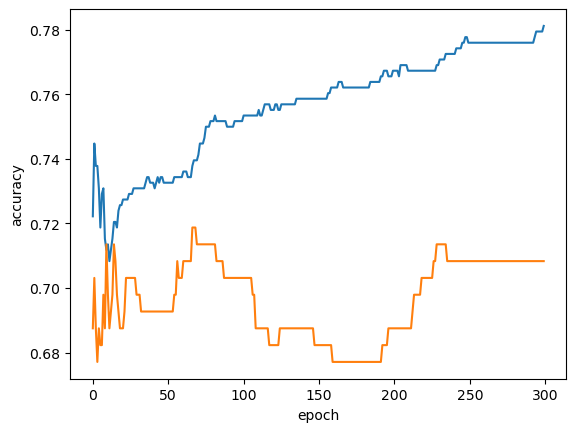

In [262]:
#300번 반복하는 동안 훈련 세트와 테스트 세트의 점수를 그려보기
import matplotlib.pyplot as plt
plt.plot(train_score) #훈련 세트 점수 그래프 그리기 = 파란색
plt.plot(test_score)  #테스트 세트 점수 그래프 그리기 = 주황색 
plt.xlabel('epoch') #x축 이름
plt.ylabel('accuracy') #y축 이름
plt.show()

점수가 너무 안나와서 random forest 추가로 학습해보기로 함
### 2.4 RandomForest-Median


In [263]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, random_state=42) # 랜덤 포레스트 분류기 객체 생성
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7759670164917543


과대적합된듯 하나, random forest는 1.0도 정상 수치?

In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=10,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 10
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9986984815618222 0.7725187406296852


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=5,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 5
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.8789069131377912 0.7655922038980509


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9522587946807507 0.7656071964017992


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7, min_samples_leaf=2, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9335961520324435 0.7638530734632683


In [ ]:
rf = RandomForestClassifier(n_jobs=-1, 
             max_depth=7, min_samples_leaf=2, min_samples_split=4, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9335961520324435 0.7638530734632683


이번에도 default 설정이 가장 높음     

gradient boost 사용해보기로
### 2.5 Gradient Boost-Median

In [269]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9544251626898047 0.7708245877061468


KNN (n=4) 이었을 때의  (0.8208, 0.7468)보다 높다...!

In [270]:
#learning_rate=0.2로
gb = GradientBoostingClassifier(learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9978298594737339 0.7656071964017992


In [271]:
#n_estimators를 500으로
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7569565217391304


또 과대적합이다. 200으로 해보기로.

In [272]:
#n_estimators를 200으로
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7673613193403298


In [273]:
#n_estimators를 50으로
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9583372630387625 0.7708245877061469


다른 하이퍼파라미터 조정해보자. learning_rate를 0.3으로?

In [274]:
gb = GradientBoostingClassifier(learning_rate=0.3, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7569115442278861


In [275]:
#낮춰보자
gb = GradientBoostingClassifier(learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9092869942469111 0.7655472263868066


In [276]:
#트리 개수를 높이되, learning_rate을 0.05로?
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.955293784777893 0.7638680659670165


In [277]:
#트리 개수를 높이되, learning_rate을 0.05로?
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9869782137131 0.7690704647676161


### 2.6. 히스토그램 기반 그레디언트 부스팅


In [356]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7430584707646177


In [357]:
from sklearn.inspection import permutation_importance
hgb.fit(train_input, train_target)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)  

[0.01302083 0.2328125  0.04635417 0.02204861 0.02482639 0.10763889
 0.07309028 0.10017361]


In [358]:
# histgradientboostingclassifier 모델을 통해 테스트 세트 성능 최종 확인
hgb.score(test_input, test_target)

0.7291666666666666

In [352]:
from xgboost import XGBClassifier
xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.737751124437781


Mean에서 모델 별 score
|model|	train score|	test score
|---|---|---
|knn(n=4)|0.8208|0.7468
|LR(SGD)|0.7829|0.7291
|RF |1.0 |0.75515
|RF(max=7)|0.9605| 0.7499
|GB(Default)|0.9544| 0.7708
|GB(n-300, r=0.05)|0.9865| 0.7569

Gradient Boosting 기본이 가장 좋아보인다.


## 3. 전처리 방법. KNN Imputer 사용 (scikit-learn)

In [278]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head())

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


In [279]:
#0을 결측치 처리

zero_cols = ["Glucose_Concentration", "BP", "Skin_Thickness", "Serum_Insulin", "BMI"]
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[zero_cols] = imputer.fit_transform(df[zero_cols])

### 3.1 KNN-KNN

In [280]:
x = df[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
        "Serum_Insulin", "BMI", "Diabetes_Pedigree_Function", "Age"]]

y = df["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [281]:
#표준화 처리
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [282]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target) #훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8208469055374593
0.6623376623376623


mean(0.8013029315960912, 0.6753246753246753) 과 거의 유사하다.

### 3.2 KNN의 이웃수를 변경해보기  

In [283]:
x = df[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
        "Serum_Insulin", "BMI", "Diabetes_Pedigree_Function", "Age"]]

y = df["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [284]:
# K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8599348534201955
0.6948051948051948


역시나 mean 보다는 조금 나은 성적       
0.8420195439739414
0.6818181818181818

In [285]:
# K-최근접 이웃 분류기 훈련하기 n=2
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=2) # 최근접 이웃 2개로
kn.fit(train_scaled, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_scaled, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_scaled, test_target)) # 테스트 세트로 모델 평가

0.8387622149837134
0.6883116883116883


In [286]:
# K-최근접 이웃 분류기 훈련하기 n=4
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=4) # 최근접 이웃 4개로
kn.fit(train_scaled, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_scaled, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_scaled, test_target)) # 테스트 세트로 모델 평가

0.7931596091205212
0.7272727272727273


오히려 여기서는 
|n_neighbors|	train score|	test score
|---|---|---
|2|0.8387|0.6883
|3	|0.8599|0.6948
|4|0.79315|0.7272
|5(Default)	|0.8599|0.6948

4나 5?


### 3.3 LogisticRegression-KNN

In [287]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)
#0을 결측치 처리

zero_cols = ["Glucose_Concentration", "BP", "Skin_Thickness", "Serum_Insulin", "BMI"]
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[zero_cols] = imputer.fit_transform(df[zero_cols])

In [288]:
from sklearn.model_selection import train_test_split
# 훈련 세트와 테스트 세트로 분할
train_input, test_input, train_target, test_target = train_test_split(
    data_input, data_target, random_state=42)

In [289]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [290]:
#당뇨 1 정상 0 이진 분류 수행
dm_indexes = (train_target == 1) | (train_target == 0) # 타깃이 도미인것만 true로 OR 타깃이 빙어인것만 true로 
train_dm = train_scaled[dm_indexes] #train_scaled (표준화한 데이터 셋)에서 dm_indexes가 True인 행만 선택
traget_dm = train_target[dm_indexes] #train_target (타깃값)에서 dm_indexes가 True인 행만 선택

In [291]:
print(dm_indexes)

357    True
73     True
352    True
497    True
145    True
       ... 
71     True
106    True
270    True
435    True
102    True
Name: Outcome, Length: 576, dtype: bool


In [292]:
# 로지스틱 회귀 모델을 훈련
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 불러오기
lr = LogisticRegression() # 모델 객체 생성
lr.fit(train_dm, traget_dm) # 당뇨 데이터로 모델 훈련

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [293]:
print(lr.predict(train_dm[:5])) # 처음 5개 샘플 예측


[1 0 0 0 0]


In [294]:
print(lr.predict_proba(train_dm[:5])) # 처음 5개 샘플의 클래스별 확률

[[0.09844234 0.90155766]
 [0.7781456  0.2218544 ]
 [0.91921861 0.08078139]
 [0.94766155 0.05233845]
 [0.99507529 0.00492471]]


In [295]:
print(lr.classes_)

[0 1]


In [296]:
#확률로 변경해보기
from scipy.special import expit # 시그모이드 함수 불러오기
print(expit(decisions)) # 결정 함수 값에 시그모이드 함수 적용하여 확률 계산


[0.27124893 0.1897974  0.10964114 0.14850225 0.48077318 0.44684593
 0.01394938 0.6181422  0.56485178 0.78659934]


In [297]:
#LogisticRegression 클래스로 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000) # 규제 강도 C를 20으로, 최대 반복 횟수 1000으로 설정
lr.fit(train_scaled, train_target) # 전체 훈련 세트로 모델 훈련
print(lr.score(train_scaled, train_target)) # 훈련 세트 점수 출력
print(lr.score(test_scaled, test_target)) # 테스트 세트 점수 출력

0.78125
0.7291666666666666


In [298]:
# 테스트 세트의 처음 10개 샘플의 클래스별 예측 출력
print(lr.predict(test_scaled[:10]))

[0 0 0 0 0 0 0 1 1 1]


In [299]:
#테스트 세트의 처음 5개 샘플의 클래스별 확률 출력
proba = lr.predict_proba(test_scaled[:10])
print(np.round(proba, decimals=3))


[[0.729 0.271]
 [0.81  0.19 ]
 [0.89  0.11 ]
 [0.851 0.149]
 [0.519 0.481]
 [0.553 0.447]
 [0.986 0.014]
 [0.382 0.618]
 [0.435 0.565]
 [0.213 0.787]]


In [300]:
sc.partial_fit(train_scaled, train_target) #훈련 세트로 모델을 이어서 훈련
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.78125
0.7083333333333334


median (0.7222, 0.6666)       

knn (0.7812, 0.7239)

In [301]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)
#0을 결측치 처리

zero_cols = ["Glucose_Concentration", "BP", "Skin_Thickness", "Serum_Insulin", "BMI"]
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[zero_cols] = imputer.fit_transform(df[zero_cols])

In [302]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42) #SGDClassifier 객체 생성
train_score = [] 
test_score = [] 
classes = np.unique(train_target) #고유한 타깃 클래스 배열 생성

In [303]:
for i in range(300): #300번 반복
    sc.partial_fit(train_scaled, train_target, classes=classes) #부분 훈련 수행
    train_score.append(sc.score(train_scaled, train_target)) #훈련 세트 점수 저장
    test_score.append(sc.score(test_scaled, test_target)) #테스트 세트 점수 저장

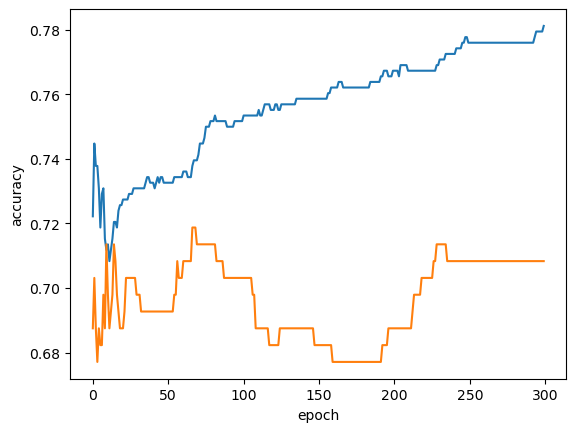

In [304]:
#300번 반복하는 동안 훈련 세트와 테스트 세트의 점수를 그려보기
import matplotlib.pyplot as plt
plt.plot(train_score) #훈련 세트 점수 그래프 그리기 = 파란색
plt.plot(test_score)  #테스트 세트 점수 그래프 그리기 = 주황색 
plt.xlabel('epoch') #x축 이름
plt.ylabel('accuracy') #y축 이름
plt.show()

역시나 성적이 별로.     
### 3.4 RandomForest-knn


In [305]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)
#0을 결측치 처리

zero_cols = ["Glucose_Concentration", "BP", "Skin_Thickness", "Serum_Insulin", "BMI"]
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[zero_cols] = imputer.fit_transform(df[zero_cols])

In [306]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, random_state=42) # 랜덤 포레스트 분류기 객체 생성
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7759670164917543


In [307]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=10,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 10
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9986984815618222 0.7725187406296852


In [308]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=5,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 5
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.8789069131377912 0.7655922038980509


In [309]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9522587946807507 0.7656071964017992


In [310]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7, min_samples_leaf=2, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9335961520324435 0.7638530734632683


In [311]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, 
             max_depth=7, min_samples_leaf=2, min_samples_split=4, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9335961520324435 0.7638530734632683


Median과 차이가 없다..
### 3.5 Gradient Boost-knn

In [312]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)
#0을 결측치 처리

zero_cols = ["Glucose_Concentration", "BP", "Skin_Thickness", "Serum_Insulin", "BMI"]
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[zero_cols] = imputer.fit_transform(df[zero_cols])

In [313]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9544251626898047 0.7708245877061468


In [314]:
#learning_rate=0.2로
gb = GradientBoostingClassifier(learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9978298594737339 0.7656071964017992


knn과 median에서 유의미한 차이가 없는 듯 하다..


# 4. insulin을 삭제해보자.
0 -> N/A로  -> INSULIN 삭제 -> N/A를 중앙값으로

In [315]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head())

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


In [316]:
zero_cols = ["Glucose_Concentration", "BP", "Skin_Thickness", "BMI"]
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

In [317]:
df = df.drop(columns=["Serum_Insulin"])


In [318]:
df = df.fillna(df.median())

## 4.1. KNN-W/O INSULIN

In [319]:
x = df[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
         "BMI", "Diabetes_Pedigree_Function", "Age"]]

y = df["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [320]:
#표준화 처리
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [321]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target) #훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8289902280130294
0.7337662337662337


높아졌다.

## 4.2 KNN이웃수 변경(W/O INSULIN)

In [322]:
x = df[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
         "BMI", "Diabetes_Pedigree_Function", "Age"]]

y = df["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [323]:
# K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8403908794788274
0.7337662337662337


MEDIAN 대비 TEST SCORE가 높아졌다.      
median(0.8420,
0.6818)

In [324]:
print(test_input)

     n_Pregnancies  Glucose_Concentration     BP  Skin_Thickness   BMI  \
44               7                  159.0   64.0            29.0  27.4   
672             10                   68.0  106.0            23.0  35.5   
700              2                  122.0   76.0            27.0  35.9   
630              7                  114.0   64.0            29.0  27.4   
81               2                   74.0   72.0            29.0  32.3   
..             ...                    ...    ...             ...   ...   
32               3                   88.0   58.0            11.0  24.8   
637              2                   94.0   76.0            18.0  31.6   
593              2                   82.0   52.0            22.0  28.5   
425              4                  184.0   78.0            39.0  37.0   
273              1                   71.0   78.0            50.0  33.2   

     Diabetes_Pedigree_Function  Age  
44                        0.294   40  
672                       0.285  

In [325]:
# K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
kn.fit(train_scaled, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_scaled, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_scaled, test_target)) # 테스트 세트로 모델 평가

0.8403908794788274
0.7337662337662337


In [326]:
# K-최근접 이웃 분류기 훈련하기 n=2
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=2) # 최근접 이웃 2개로
kn.fit(train_scaled, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_scaled, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_scaled, test_target)) # 테스트 세트로 모델 평가

0.8387622149837134
0.7142857142857143


In [327]:
# K-최근접 이웃 분류기 훈련하기 n=4
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=4) # 최근접 이웃 4개로
kn.fit(train_scaled, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_scaled, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_scaled, test_target)) # 테스트 세트로 모델 평가

0.8175895765472313
0.7337662337662337


|n_neighbors|	train score|	test score
|---|---|---
|2(m)|0.8436|0.7273
|2(w/o i)|0.8387|0.7142
|3(m)	|0.8469	|0.7208
|3(w/o i)|0.8403|0.7337
|4(m)|0.8208|0.7468
|4(w/o i)|0.8175|0.7337
|5(Default)	|0.8013	|0.6753
|5(w/o i)|0.8289|0.7337


딱히 유의미한 차이가 없어보인다.



## 4.3 LogisticRegression w/o insulin

In [328]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head())

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


In [329]:
zero_cols = ["Glucose_Concentration", "BP", "Skin_Thickness", "BMI"]
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
df = df.drop(columns=["Serum_Insulin"])
df = df.fillna(df.median())

In [330]:
from sklearn.model_selection import train_test_split
# 훈련 세트와 테스트 세트로 분할
train_input, test_input, train_target, test_target = train_test_split(
    data_input, data_target, random_state=42)

In [331]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [332]:
#당뇨 1 정상 0 이진 분류 수행
dm_indexes = (train_target == 1) | (train_target == 0) # 타깃이 도미인것만 true로 OR 타깃이 빙어인것만 true로 
train_dm = train_scaled[dm_indexes] #train_scaled (표준화한 데이터 셋)에서 dm_indexes가 True인 행만 선택
traget_dm = train_target[dm_indexes] #train_target (타깃값)에서 dm_indexes가 True인 행만 선택

In [333]:
print(dm_indexes)

357    True
73     True
352    True
497    True
145    True
       ... 
71     True
106    True
270    True
435    True
102    True
Name: Outcome, Length: 576, dtype: bool


In [334]:
# 로지스틱 회귀 모델을 훈련
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 불러오기
lr = LogisticRegression() # 모델 객체 생성
lr.fit(train_dm, traget_dm) # 당뇨 데이터로 모델 훈련

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [335]:
print(lr.predict(train_dm[:5])) # 처음 5개 샘플 예측


[1 0 0 0 0]


In [336]:
print(lr.predict_proba(train_dm[:5])) # 처음 5개 샘플의 클래스별 확률

[[0.09844234 0.90155766]
 [0.7781456  0.2218544 ]
 [0.91921861 0.08078139]
 [0.94766155 0.05233845]
 [0.99507529 0.00492471]]


In [337]:
#확률로 변경해보기
from scipy.special import expit # 시그모이드 함수 불러오기
print(expit(decisions)) # 결정 함수 값에 시그모이드 함수 적용하여 확률 계산


[0.27124893 0.1897974  0.10964114 0.14850225 0.48077318 0.44684593
 0.01394938 0.6181422  0.56485178 0.78659934]


In [338]:
#LogisticRegression 클래스로 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000) # 규제 강도 C를 20으로, 최대 반복 횟수 1000으로 설정
lr.fit(train_scaled, train_target) # 전체 훈련 세트로 모델 훈련
print(lr.score(train_scaled, train_target)) # 훈련 세트 점수 출력
print(lr.score(test_scaled, test_target)) # 테스트 세트 점수 출력

0.78125
0.7291666666666666


In [339]:
#테스트 세트의 처음 5개 샘플의 클래스별 확률 출력
proba = lr.predict_proba(test_scaled[:10])
print(np.round(proba, decimals=3))


[[0.729 0.271]
 [0.81  0.19 ]
 [0.89  0.11 ]
 [0.851 0.149]
 [0.519 0.481]
 [0.553 0.447]
 [0.986 0.014]
 [0.382 0.618]
 [0.435 0.565]
 [0.213 0.787]]


In [340]:
#표준편차로
from sklearn.linear_model import SGDClassifier #SGDClassifier 불러오기
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42) #로지스틱 회귀를 수행하는 SGDClassifier 객체 생성
sc.fit(train_scaled, train_target) #훈련 세트로 SGDClassifier 객체를 만듦
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.7013888888888888
0.671875


/home/hykim/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [341]:
sc.partial_fit(train_scaled, train_target) #훈련 세트로 모델을 이어서 훈련
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.7100694444444444
0.6979166666666666


In [342]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42) #SGDClassifier 객체 생성
train_score = [] 
test_score = [] 
classes = np.unique(train_target) #고유한 타깃 클래스 배열 생성

In [343]:
for i in range(300): #300번 반복
    sc.partial_fit(train_scaled, train_target, classes=classes) #부분 훈련 수행
    train_score.append(sc.score(train_scaled, train_target)) #훈련 세트 점수 저장
    test_score.append(sc.score(test_scaled, test_target)) #테스트 세트 점수 저장

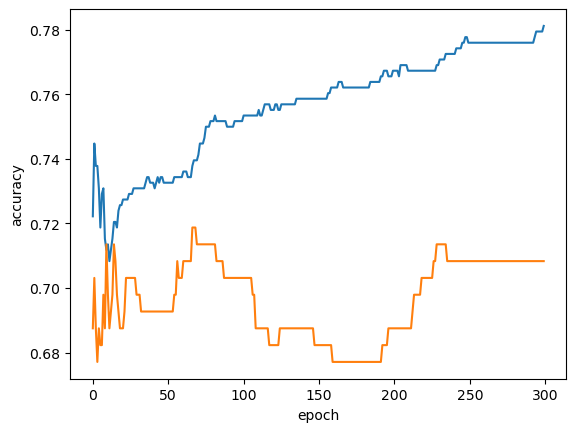

In [344]:
#300번 반복하는 동안 훈련 세트와 테스트 세트의 점수를 그려보기
import matplotlib.pyplot as plt
plt.plot(train_score) #훈련 세트 점수 그래프 그리기 = 파란색
plt.plot(test_score)  #테스트 세트 점수 그래프 그리기 = 주황색 
plt.xlabel('epoch') #x축 이름
plt.ylabel('accuracy') #y축 이름
plt.show()

역시 점수가 너무 안나와서 random forest 추가로 학습해보기로 함
## 4.4 RandomForest-w/o insulin


In [345]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, random_state=42) # 랜덤 포레스트 분류기 객체 생성
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7759670164917543


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=10,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 10
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9986984815618222 0.7725187406296852


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=5,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 5
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.8789069131377912 0.7655922038980509


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9522587946807507 0.7656071964017992


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7, min_samples_leaf=2, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9335961520324435 0.7638530734632683


In [ ]:
rf = RandomForestClassifier(n_jobs=-1, 
             max_depth=7, min_samples_leaf=2, min_samples_split=4, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9335961520324435 0.7638530734632683


전처리 방식이 크게 유의미하지 않은 것 같다.     
따라서, 
Mean에서 모델 별 score
|model|	train score|	test score
|---|---|---
|knn(n=4)|0.8208|0.7468
|LR(SGD)|0.7829|0.7291
|RF |1.0 |0.75515
|RF(max=7)|0.9605| 0.7499
|GB(Default)|0.9652| 0.7602
|GB(n-300, r=0.05)|0.9865| 0.7569

RANDOM FOREST를 가지고 학습해보자

## 4.5 최종 학습


In [359]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, random_state=42) # 랜덤 포레스트 분류기 객체 생성
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7759670164917543


In [360]:
rf.fit(train_input, train_target)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [361]:

print("train score:", rf.score(train_input, train_target))

train score: 1.0


In [362]:
test_score = rf.score(test_input, test_target)
print("test score:", test_score)

test score: 0.734375


In [363]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9544251626898047 0.7708245877061468


In [364]:
gb.fit(train_input, train_target)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [365]:

print("train score:", gb.score(train_input, train_target))

train score: 0.9409722222222222


In [366]:
test_score = gb.score(test_input, test_target)
print("test score:", test_score)

test score: 0.7395833333333334


# 5. 0값을 모두 제거하고 모델을 학습해보자



In [40]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head());

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


In [43]:
# 0값제거
df[(df['n_Pregnancies'] != 0) & 
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]


,n_Pregnancies,Glucose_Concentration,BP,Skin_Thickness,Serum_Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
3,1,89,66,23,94,28.1,0.167,21,0
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0


In [44]:
#0값 제거한 것 저장
df_wo_z=df[(df['n_Pregnancies'] != 0) & 
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0) & 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]

만약. feature가 너무 많다면?
임신회수, 인슐린 열을 다 지우고, 
bp >120 인것 제외


In [45]:
#인슐린, 임신횟수 제거
df_wo_zip = df_wo_z.drop(columns=["Serum_Insulin", "n_Pregnancies"])

In [46]:
display(df_wo_zip)

,Glucose_Concentration,BP,Skin_Thickness,BMI,Diabetes_Pedigree_Function,Age,Outcome
0,148,72,35,33.6,0.627,50,1
1,85,66,29,26.6,0.351,31,0
3,89,66,23,28.1,0.167,21,0
6,78,50,32,31.0,0.248,26,1
8,197,70,45,30.5,0.158,53,1
...,...,...,...,...,...,...,...
761,170,74,31,44.0,0.403,43,1
763,101,76,48,32.9,0.171,63,0
764,122,70,27,36.8,0.340,27,0
765,121,72,23,26.2,0.245,30,0


In [48]:
x = df[[ "Glucose_Concentration", "BP", "Skin_Thickness",
         "BMI", "Diabetes_Pedigree_Function", "Age"]]

y = df["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target) #훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8485342019543974
0.7012987012987013


훈련/테스트 모두 올라갔다.

In [50]:
# K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8648208469055375
0.6948051948051948


In [53]:
# K-최근접 이웃 분류기 훈련하기 n=2

from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=2) # 최근접 이웃 2개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8322475570032574
0.7142857142857143


In [55]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)
#0값 제거한 것 저장
df_wo_z=df[(df['n_Pregnancies'] != 0) & 
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0) & 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]
#인슐린, 임신횟수 제거
df_wo_zip = df_wo_z.drop(columns=["Serum_Insulin", "n_Pregnancies"])

In [56]:
x = df[[ "Glucose_Concentration", "BP", "Skin_Thickness",
         "BMI", "Diabetes_Pedigree_Function", "Age"]]

y = df["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)


In [57]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [58]:
#당뇨 1 정상 0 이진 분류 수행
dm_indexes = (train_target == 1) | (train_target == 0) # 타깃이 도미인것만 true로 OR 타깃이 빙어인것만 true로 
train_dm = train_scaled[dm_indexes] #train_scaled (표준화한 데이터 셋)에서 dm_indexes가 True인 행만 선택
traget_dm = train_target[dm_indexes] #train_target (타깃값)에서 dm_indexes가 True인 행만 선택

In [59]:
# 로지스틱 회귀 모델을 훈련
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 불러오기
lr = LogisticRegression() # 모델 객체 생성
lr.fit(train_dm, traget_dm) # 당뇨 데이터로 모델 훈련

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [60]:
decisions = lr.decision_function(train_dm[:5]) # 처음 5개 샘플의 결정 함수 값 계산
print(decisions)

[-2.49565172 -0.80606129 -1.48609    -0.14170585 -1.01597324]


In [61]:
#확률로 변경해보기
from scipy.special import expit # 시그모이드 함수 불러오기
print(expit(decisions)) # 결정 함수 값에 시그모이드 함수 적용하여 확률 계산


[0.07616357 0.30873045 0.18450932 0.4646327  0.26581251]


In [62]:
#LogisticRegression 클래스로 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000) # 규제 강도 C를 20으로, 최대 반복 횟수 1000으로 설정
lr.fit(train_scaled, train_target) # 전체 훈련 세트로 모델 훈련
print(lr.score(train_scaled, train_target)) # 훈련 세트 점수 출력
print(lr.score(test_scaled, test_target)) # 테스트 세트 점수 출력

0.7915309446254072
0.7272727272727273


In [63]:
# 테스트 세트의 처음 10개 샘플의 클래스별 예측 출력
print(lr.predict(test_scaled[:10]))

[1 0 0 0 0 0 0 1 0 1]


In [64]:
#표준편차로
from sklearn.linear_model import SGDClassifier #SGDClassifier 불러오기
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42) #로지스틱 회귀를 수행하는 SGDClassifier 객체 생성
sc.fit(train_scaled, train_target) #훈련 세트로 SGDClassifier 객체를 만듦
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.5716612377850163
0.5584415584415584


/home/hykim/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [65]:
sc.partial_fit(train_scaled, train_target) #훈련 세트로 모델을 이어서 훈련
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.7296416938110749
0.6558441558441559


In [66]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42) #SGDClassifier 객체 생성
train_score = [] 
test_score = [] 
classes = np.unique(train_target) #고유한 타깃 클래스 배열 생성

In [67]:
for i in range(300): #300번 반복
    sc.partial_fit(train_scaled, train_target, classes=classes) #부분 훈련 수행
    train_score.append(sc.score(train_scaled, train_target)) #훈련 세트 점수 저장
    test_score.append(sc.score(test_scaled, test_target)) #테스트 세트 점수 저장

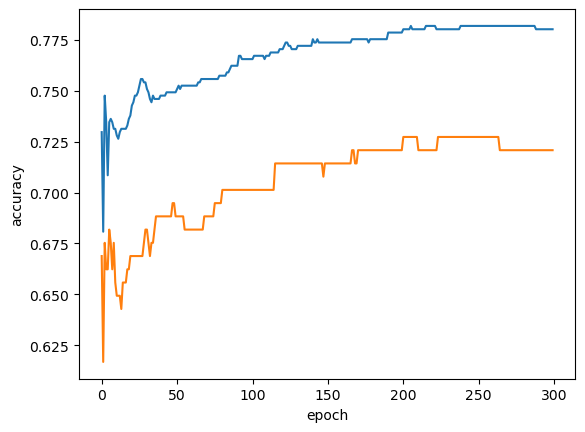

In [68]:
#300번 반복하는 동안 훈련 세트와 테스트 세트의 점수를 그려보기
import matplotlib.pyplot as plt
plt.plot(train_score) #훈련 세트 점수 그래프 그리기 = 파란색
plt.plot(test_score)  #테스트 세트 점수 그래프 그리기 = 주황색 
plt.xlabel('epoch') #x축 이름
plt.ylabel('accuracy') #y축 이름
plt.show()

## 5.4 RandomForest

In [69]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, random_state=42) # 랜덤 포레스트 분류기 객체 생성
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7687591630014661


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=10,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 10
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9991853360488798 0.7638811142209783


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=5,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 5
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.866859569817694 0.7753298680527789


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9348533770470088 0.7655737704918033


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7, min_samples_leaf=2, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9128706969350754 0.7704251632680262


In [ ]:
rf = RandomForestClassifier(n_jobs=-1, 
             max_depth=7, min_samples_leaf=2, min_samples_split=4, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9128706969350754 0.7704251632680262


## 5.5 Gradient Boost

In [75]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9283451724537611 0.7444089031054245


In [76]:
#learning_rate=0.2로
gb = GradientBoostingClassifier(learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9902290000496745 0.7248034119685459


In [77]:
#n_estimators를 500으로
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.744368919099027


In [78]:
#n_estimators를 200으로
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7362121817939491


In [79]:
#낮춰보자
gb = GradientBoostingClassifier(learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8815168976537017 0.7655604424896707


# 6. test set을 반복 사용한 것을 알게 되었다.

test set은 마지막에 한 번만 사용해야하는데, 책 내용을 활용하다보니  
학습할 때마다 test set score을 매번 실행했다.   `   
이제, 교차 검증 val set을 사용해보기로 한다.        
    

# 7. 다시 0값을 모두 제거하고 모델을 학습해보자

In [1]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head());

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


In [2]:
# 0값제거
df[(df['Serum_Insulin'] != 0) &
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]


,n_Pregnancies,Glucose_Concentration,BP,Skin_Thickness,Serum_Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


In [3]:
#0값 제거한 것 저장
df_wo_z=df[(df['Serum_Insulin'] != 0) &
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]

In [4]:
display(df_wo_z)

,n_Pregnancies,Glucose_Concentration,BP,Skin_Thickness,Serum_Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


In [5]:
x = df_wo_z[['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age']]

y = df_wo_z["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target) #훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

In [10]:
# K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8690095846645367
0.7341772151898734


In [11]:
# K-최근접 이웃 분류기 훈련하기 n=2
kn = KNeighborsClassifier(n_neighbors=2) # 최근접 이웃 2개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8402555910543131
0.7215189873417721


In [12]:
# K-최근접 이웃 분류기 훈련하기 n=4
kn = KNeighborsClassifier(n_neighbors=4) # 최근접 이웃 4개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8146964856230032
0.7341772151898734


|n_neighbors|	train score|	test score
|---|---|---
|2|0.8436|0.7273
|2_0|0.8690|0.7341
|3	|0.8469	|0.7208
|3_0|0.8402|0.7215
|4|**0.8208**|**0.7468**
|4_0|0.8146|0.7341
|5(Default)	|0.8013	|0.6753
|5_0|**0.7987**|**0.7848**

### LogisticRegression

In [13]:
data_input = df_wo_z[["n_Pregnancies", "Glucose_Concentration", "BP", "Skin_Thickness",
        "Serum_Insulin", "BMI", "Diabetes_Pedigree_Function", "Age"]]

data_target = df_wo_z["Outcome"]

In [14]:
from sklearn.model_selection import train_test_split
# 훈련 세트와 테스트 세트로 분할
train_input, test_input, train_target, test_target = train_test_split(
    data_input, data_target, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [16]:
#당뇨 1 정상 0 이진 분류 수행
dm_indexes = (train_target == 1) | (train_target == 0) # 타깃이 도미인것만 true로 OR 타깃이 빙어인것만 true로 
train_dm = train_scaled[dm_indexes] #train_scaled (표준화한 데이터 셋)에서 dm_indexes가 True인 행만 선택
traget_dm = train_target[dm_indexes] #train_target (타깃값)에서 dm_indexes가 True인 행만 선택

In [17]:
# 로지스틱 회귀 모델을 훈련
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 불러오기
lr = LogisticRegression() # 모델 객체 생성
lr.fit(train_dm, traget_dm) # 당뇨 데이터로 모델 훈련

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
print(lr.predict(train_dm[:5])) # 처음 5개 샘플 예측


[0 0 0 0 0]


In [ ]:
print(lr.predict_proba(train_dm[:5])) # 처음 5개 샘플의 클래스별 확률

[[0.61593219 0.38406781]
 [0.84450802 0.15549198]
 [0.96354022 0.03645978]
 [0.97020214 0.02979786]
 [0.88095035 0.11904965]]


In [ ]:
print(lr.classes_)

[0 1]


In [ ]:
decisions = lr.decision_function(train_dm[:5]) # 처음 5개 샘플의 결정 함수 값 계산
print(decisions)

[-0.47231775 -1.69216004 -3.27440439 -3.48306792 -2.00146066]


In [ ]:
#확률로 변경해보기
from scipy.special import expit # 시그모이드 함수 불러오기
print(expit(decisions)) # 결정 함수 값에 시그모이드 함수 적용하여 확률 계산


[0.38406781 0.15549198 0.03645978 0.02979786 0.11904965]


In [ ]:
#LogisticRegression 클래스로 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000) # 규제 강도 C를 20으로, 최대 반복 횟수 1000으로 설정
lr.fit(train_scaled, train_target) # 전체 훈련 세트로 모델 훈련
print(lr.score(train_scaled, train_target)) # 훈련 세트 점수 출력
print(lr.score(test_scaled, test_target)) # 테스트 세트 점수 출력

0.8061224489795918
0.7551020408163265


In [ ]:
#테스트 세트의 처음 5개 샘플의 클래스별 확률 출력
proba = lr.predict_proba(test_scaled[:10])
print(np.round(proba, decimals=3))


[[0.758 0.242]
 [0.666 0.334]
 [0.972 0.028]
 [0.119 0.881]
 [0.147 0.853]
 [0.883 0.117]
 [0.994 0.006]
 [0.957 0.043]
 [0.305 0.695]
 [0.937 0.063]]


In [ ]:
#선형 방정식으로 만들어보기.
print(lr.coef_.shape, lr.intercept_.shape)

(1, 8) (1,)


In [ ]:
#decision_function을 이용하여 z1 값 계산하기
decisions = lr.decision_function(test_scaled[:10])
print(np.round(decisions, decimals=2))

[-1.14 -0.69 -3.53  2.    1.76 -2.02 -5.13 -3.11  0.82 -2.7 ]


In [ ]:
#표준편차로
from sklearn.linear_model import SGDClassifier #SGDClassifier 불러오기
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42) #로지스틱 회귀를 수행하는 SGDClassifier 객체 생성
sc.fit(train_scaled, train_target) #훈련 세트로 SGDClassifier 객체를 만듦
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.7210884353741497
0.6836734693877551


/home/hykim/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
sc.partial_fit(train_scaled, train_target) #훈련 세트로 모델을 이어서 훈련
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.6496598639455783
0.6020408163265306


In [ ]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42) #SGDClassifier 객체 생성
train_score = [] 
test_score = [] 
classes = np.unique(train_target) #고유한 타깃 클래스 배열 생성

In [ ]:
for i in range(300): #300번 반복
    sc.partial_fit(train_scaled, train_target, classes=classes) #부분 훈련 수행
    train_score.append(sc.score(train_scaled, train_target)) #훈련 세트 점수 저장
    test_score.append(sc.score(test_scaled, test_target)) #테스트 세트 점수 저장

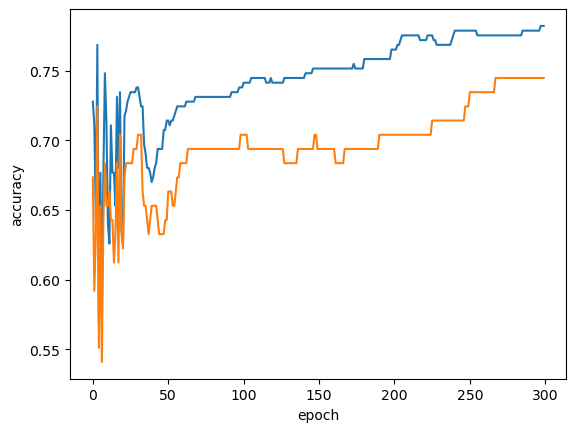

In [ ]:
#300번 반복하는 동안 훈련 세트와 테스트 세트의 점수를 그려보기
import matplotlib.pyplot as plt
plt.plot(train_score) #훈련 세트 점수 그래프 그리기 = 파란색
plt.plot(test_score)  #테스트 세트 점수 그래프 그리기 = 주황색 
plt.xlabel('epoch') #x축 이름
plt.ylabel('accuracy') #y축 이름
plt.show()

###  RandomForest-0제거

In [ ]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)
#0값 제거한 것 저장
df_wo_z=df[(df['n_Pregnancies'] != 0) & 
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0) & 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]


In [ ]:

x = df_wo_z[['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age']]

y = df_wo_z["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, random_state=42) # 랜덤 포레스트 분류기 객체 생성
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7801750380517504


In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=10,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 10
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7774353120243531


In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=5,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 5
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9189615402720896 0.7802130898021309


In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9759685543473144 0.7938736681887366


In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7, min_samples_leaf=2, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9526196864849596 0.7856544901065449


### 7.5 Gradient Boost-0값 제거

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9897001365155582 0.7911339421613394


In [ ]:
#learning_rate=0.2로
gb = GradientBoostingClassifier(learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9993150684931507 0.7665144596651446


In [ ]:
#n_estimators를 500으로
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7664383561643835


In [ ]:
#n_estimators를 200으로
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7609969558599695


In [ ]:
#n_estimators를 50으로
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9917596384691428 0.7747336377473364


In [ ]:
gb = GradientBoostingClassifier(learning_rate=0.3, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7746575342465754


In [ ]:
#낮춰보자
gb = GradientBoostingClassifier(learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9388833968836794 0.7746575342465754


In [ ]:
#트리 개수를 높이되, learning_rate을 0.05로?
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9890152050087089 0.7829147640791476


In [ ]:
#트리 개수를 높이되, learning_rate을 0.05로?
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.997255566539566 0.7692161339421613


### 7.6. 히스토그램 기반 그레디언트 부스팅


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9993127147766323 0.7636986301369862


In [ ]:
from sklearn.inspection import permutation_importance
hgb.fit(train_input, train_target)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)  

[0.03186813 0.19697802 0.0206044  0.02884615 0.02417582 0.09038462
 0.0706044  0.09203297]


In [ ]:
# histgradientboostingclassifier 모델을 통해 테스트 세트 성능 최종 확인
hgb.score(test_input, test_target)

0.7802197802197802

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.744406392694064


그래도 80까지 못가는 점수..         
다른 방법을 시도해보기로 했다.      
인슐린과 임신 횟수 모두 지우고, 0값을 제거하기로.       

# 8. 0값을 모두 제거하고, 인슐린, 임신 지우고 모델을 학습해보자

In [ ]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head());

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


In [ ]:
# 0값제거
df[(df['Serum_Insulin'] != 0) &
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]


,n_Pregnancies,Glucose_Concentration,BP,Skin_Thickness,Serum_Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


In [ ]:
#0값 제거한 것 저장
df_wo_z=df[(df['Serum_Insulin'] != 0) &
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]

In [ ]:
df_wo_zi = df_wo_z.drop(columns=["Serum_Insulin"])
df_wo_zip = df_wo_zi.drop(columns=["n_Pregnancies"])

In [ ]:
display(df_wo_zip)

,Glucose_Concentration,BP,Skin_Thickness,BMI,Diabetes_Pedigree_Function,Age,Outcome
3,89,66,23,28.1,0.167,21,0
4,137,40,35,43.1,2.288,33,1
6,78,50,32,31.0,0.248,26,1
8,197,70,45,30.5,0.158,53,1
13,189,60,23,30.1,0.398,59,1
...,...,...,...,...,...,...,...
753,181,88,44,43.3,0.222,26,1
755,128,88,39,36.5,1.057,37,1
760,88,58,26,28.4,0.766,22,0
763,101,76,48,32.9,0.171,63,0


In [ ]:
x = df_wo_zip[[ 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                 'BMI', 'Diabetes_Pedigree_Function', 'Age']]

y = df_wo_zip["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target) #훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8083067092651757
0.7721518987341772


In [ ]:
# K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8498402555910544
0.7341772151898734


In [ ]:
# K-최근접 이웃 분류기 훈련하기 n=2
kn = KNeighborsClassifier(n_neighbors=2) # 최근접 이웃 2개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.8785942492012779
0.7468354430379747


In [ ]:
# K-최근접 이웃 분류기 훈련하기 n=4
kn = KNeighborsClassifier(n_neighbors=4) # 최근접 이웃 4개로
kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가

0.7987220447284346
0.759493670886076


|n_neighbors|	train score|	test score
|---|---|---
|2|0.8436|0.7273
|2_0|0.8690|0.7341
|2_0_wo|0.8785|0.7468
|3	|0.8469	|0.7208
|3_0|0.8402|0.7215
|3_0_wo|0.8498|0.7341
|4|**0.8208**|**0.7468**
|4_0|0.8146|0.7341
|4_0_wo|0.7987|0.7594
|5(Default)	|0.8013	|0.6753
|5_0|**0.7987**|**0.7848**
|5_0_wo|**0.8083**|**0.7721**

### LogisticRegression

In [ ]:
data_input = df_wo_zip[["Glucose_Concentration", "BP", "Skin_Thickness",
       "BMI", "Diabetes_Pedigree_Function", "Age"]]

data_target = df_wo_zip["Outcome"]

In [ ]:
from sklearn.model_selection import train_test_split
# 훈련 세트와 테스트 세트로 분할
train_input, test_input, train_target, test_target = train_test_split(
    data_input, data_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # 훈련 세트로 표준화 기준 설정
train_scaled = ss.transform(train_input) # 훈련 세트 변환
test_scaled = ss.transform(test_input) # 테스트 세트 변환

In [ ]:
#당뇨 1 정상 0 이진 분류 수행
dm_indexes = (train_target == 1) | (train_target == 0) # 타깃이 도미인것만 true로 OR 타깃이 빙어인것만 true로 
train_dm = train_scaled[dm_indexes] #train_scaled (표준화한 데이터 셋)에서 dm_indexes가 True인 행만 선택
traget_dm = train_target[dm_indexes] #train_target (타깃값)에서 dm_indexes가 True인 행만 선택

In [ ]:
# 로지스틱 회귀 모델을 훈련
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 불러오기
lr = LogisticRegression() # 모델 객체 생성
lr.fit(train_dm, traget_dm) # 당뇨 데이터로 모델 훈련

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
print(lr.predict(train_dm[:5])) # 처음 5개 샘플 예측


[0 0 0 0 0]


In [ ]:
print(lr.predict_proba(train_dm[:5])) # 처음 5개 샘플의 클래스별 확률

[[0.56458481 0.43541519]
 [0.85809795 0.14190205]
 [0.95681879 0.04318121]
 [0.966943   0.033057  ]
 [0.83608532 0.16391468]]


In [ ]:
decisions = lr.decision_function(train_dm[:5]) # 처음 5개 샘플의 결정 함수 값 계산
print(decisions)

[-0.25979056 -1.79958121 -3.09820859 -3.37590608 -1.62938464]


In [ ]:
#확률로 변경해보기
from scipy.special import expit # 시그모이드 함수 불러오기
print(expit(decisions)) # 결정 함수 값에 시그모이드 함수 적용하여 확률 계산


[0.43541519 0.14190205 0.04318121 0.033057   0.16391468]


In [ ]:
#LogisticRegression 클래스로 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000) # 규제 강도 C를 20으로, 최대 반복 횟수 1000으로 설정
lr.fit(train_scaled, train_target) # 전체 훈련 세트로 모델 훈련
print(lr.score(train_scaled, train_target)) # 훈련 세트 점수 출력
print(lr.score(test_scaled, test_target)) # 테스트 세트 점수 출력

0.8061224489795918
0.7448979591836735


In [ ]:
#테스트 세트의 처음 5개 샘플의 클래스별 확률 출력
proba = lr.predict_proba(test_scaled[:10])
print(np.round(proba, decimals=3))


[[0.765 0.235]
 [0.647 0.353]
 [0.973 0.027]
 [0.096 0.904]
 [0.146 0.854]
 [0.861 0.139]
 [0.994 0.006]
 [0.968 0.032]
 [0.349 0.651]
 [0.95  0.05 ]]


In [ ]:
#선형 방정식으로 만들어보기.
print(lr.coef_.shape, lr.intercept_.shape)

(1, 6) (1,)


In [ ]:
#decision_function을 이용하여 z1 값 계산하기
decisions = lr.decision_function(test_scaled[:10])
print(np.round(decisions, decimals=2))

[-1.18 -0.6  -3.58  2.25  1.76 -1.82 -5.03 -3.39  0.62 -2.94]


In [ ]:
#표준편차로
from sklearn.linear_model import SGDClassifier #SGDClassifier 불러오기
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42) #로지스틱 회귀를 수행하는 SGDClassifier 객체 생성
sc.fit(train_scaled, train_target) #훈련 세트로 SGDClassifier 객체를 만듦
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.6938775510204082
0.673469387755102


/home/hykim/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
sc.partial_fit(train_scaled, train_target) #훈련 세트로 모델을 이어서 훈련
print(sc.score(train_scaled, train_target)) #훈련 세트 점수 출력
print(sc.score(test_scaled, test_target)) #테스트 세트 점수 출력

0.6632653061224489
0.6530612244897959


In [ ]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42) #SGDClassifier 객체 생성
train_score = [] 
test_score = [] 
classes = np.unique(train_target) #고유한 타깃 클래스 배열 생성

In [ ]:
for i in range(300): #300번 반복
    sc.partial_fit(train_scaled, train_target, classes=classes) #부분 훈련 수행
    train_score.append(sc.score(train_scaled, train_target)) #훈련 세트 점수 저장
    test_score.append(sc.score(test_scaled, test_target)) #테스트 세트 점수 저장

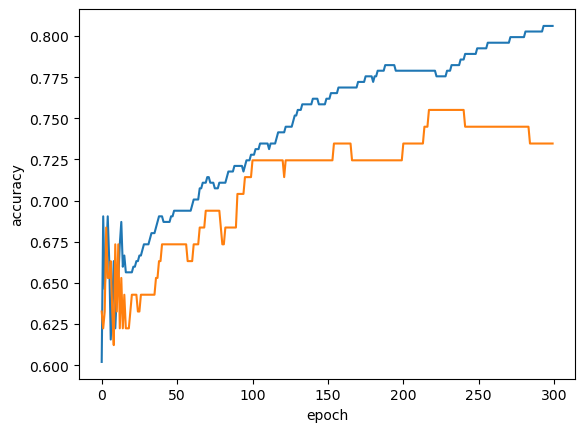

In [ ]:
#300번 반복하는 동안 훈련 세트와 테스트 세트의 점수를 그려보기
import matplotlib.pyplot as plt
plt.plot(train_score) #훈련 세트 점수 그래프 그리기 = 파란색
plt.plot(test_score)  #테스트 세트 점수 그래프 그리기 = 주황색 
plt.xlabel('epoch') #x축 이름
plt.ylabel('accuracy') #y축 이름
plt.show()

In [ ]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

# 0값제거
df[(df['Serum_Insulin'] != 0) &
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]
#0값 제거한 것 저장
df_wo_z=df[(df['Serum_Insulin'] != 0) &
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]
df_wo_zi = df_wo_z.drop(columns=["Serum_Insulin"])
df_wo_zip = df_wo_zi.drop(columns=["n_Pregnancies"])

In [ ]:

x = df_wo_z[[ 'Glucose_Concentration', 'BP', 'Skin_Thickness',
               'BMI', 'Diabetes_Pedigree_Function', 'Age']]

y = df_wo_z["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, random_state=42) # 랜덤 포레스트 분류기 객체 생성
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7925243215565796


In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=10,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 10
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

1.0 0.7925755248335893


In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.988025498007968 0.7925755248335893


In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7, min_samples_leaf=2, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 훈련 세트와 테스트 세트 점수 출력

0.9632478087649403 0.7958013312852023


### 8.5 Gradient Boost-0값 제거, insulin, preg 제거

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.989619123505976 0.7668202764976958


In [ ]:
#learning_rate=0.2로
gb = GradientBoostingClassifier(learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7507936507936508


In [ ]:
#n_estimators를 500으로
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7318484383000511


In [ ]:
#n_estimators를 200으로
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7414746543778803


In [ ]:
#n_estimators를 50으로
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.2, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9904159362549801 0.7571940604198669


In [ ]:
gb = GradientBoostingClassifier(learning_rate=0.3, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7315412186379928


In [ ]:
#낮춰보자
gb = GradientBoostingClassifier(learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))


0.9512796812749004 0.7765488991295443


In [ ]:
#트리 개수를 높이되, learning_rate을 0.05로?
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9904159362549801 0.7603686635944701


In [ ]:
#트리 개수를 높이되, learning_rate을 0.05로?
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42) 
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7507936507936508


### 8.6. 히스토그램 기반 그레디언트 부스팅


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9936063745019921 0.7827956989247312


In [ ]:
from sklearn.inspection import permutation_importance
hgb.fit(train_input, train_target)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)  

[0.22555911 0.02875399 0.04792332 0.13099042 0.08051118 0.13258786]


In [ ]:
# histgradientboostingclassifier 모델을 통해 테스트 세트 성능 최종 확인
hgb.score(test_input, test_target)

0.7721518987341772

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7250896057347671



# 9. (충격) 데이터 불러오는 것과 테스트 세트 나누는 것은 1번만 해야한다는 것도 알게 되었다.
같은 세트로 검증해야 동일한 조건에서 비교할 수 있다.        
따라서, 앞으로는 split을 1회만 실행한다음 모델별로 결과를 확인해보도록 한다.    

#9.  0값을 모두 제거하고, 인슐린, 임신 지우고 모델을 학습해보자

In [ ]:
# 데이터 불러오기
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['n_Pregnancies', 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                'Serum_Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("원본 데이터:", df.shape)
print(df.head());

원본 데이터: (768, 9)
   n_Pregnancies  Glucose_Concentration  BP  Skin_Thickness  Serum_Insulin  \
0              6                    148  72              35              0   
1              1                     85  66              29              0   
2              8                    183  64               0              0   
3              1                     89  66              23             94   
4              0                    137  40              35            168   

    BMI  Diabetes_Pedigree_Function  Age  Outcome  
0  33.6                       0.627   50        1  
1  26.6                       0.351   31        0  
2  23.3                       0.672   32        1  
3  28.1                       0.167   21        0  
4  43.1                       2.288   33        1  


In [ ]:
# 0값제거
df[(df['Serum_Insulin'] != 0) &
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]


,n_Pregnancies,Glucose_Concentration,BP,Skin_Thickness,Serum_Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


In [ ]:
#0값 제거한 것 저장
df_wo_z=df[(df['Serum_Insulin'] != 0) &
(df['BP'] != 0)& (df['Glucose_Concentration'] != 0)& 
(df['BP'] < 120)& (df['Skin_Thickness'] != 0)& (df['BMI'] != 0)]

In [ ]:
df_wo_zi = df_wo_z.drop(columns=["Serum_Insulin"])
df_wo_zip = df_wo_zi.drop(columns=["n_Pregnancies"])

In [ ]:
display(df_wo_zip)

,Glucose_Concentration,BP,Skin_Thickness,BMI,Diabetes_Pedigree_Function,Age,Outcome
3,89,66,23,28.1,0.167,21,0
4,137,40,35,43.1,2.288,33,1
6,78,50,32,31.0,0.248,26,1
8,197,70,45,30.5,0.158,53,1
13,189,60,23,30.1,0.398,59,1
...,...,...,...,...,...,...,...
753,181,88,44,43.3,0.222,26,1
755,128,88,39,36.5,1.057,37,1
760,88,58,26,28.4,0.766,22,0
763,101,76,48,32.9,0.171,63,0


In [ ]:
x = df_wo_zip[[ 'Glucose_Concentration', 'BP', 'Skin_Thickness',
                 'BMI', 'Diabetes_Pedigree_Function', 'Age']]

y = df_wo_zip["Outcome"]
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_input)
train_scaled = scaler.transform(train_input)
test_scaled = scaler.transform(test_input)

In [ ]:
'''
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(C=20, max_iter=1000)

scores = cross_val_score(
    lr,
    train_scaled,
    train_target,
    cv=5,
    scoring="roc_auc"
)

print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)
'''

CV 평균 AUC: 0.8462043028593552
CV 각 fold: [0.80725624 0.87188209 0.82993197 0.88571429 0.83623693]


In [ ]:
'''
from sklearn.neighbors import KNeighborsClassifier

k_list = [2, 3, 4, 5, 6, 7, 8]

for k in k_list:
    kn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        kn,
        train_scaled,      # ✅ 튜닝에는 train만 사용
        train_target,
        cv=5,              # 5-fold 교차검증
        scoring="accuracy" # 또는 "roc_auc" (이진분류면 가능)
    )
    print(f"k={k}, CV mean score={scores.mean():.4f}")
    '''

k=2, CV mean score=0.7283
k=3, CV mean score=0.7378
k=4, CV mean score=0.7507
k=5, CV mean score=0.7602
k=6, CV mean score=0.7635
k=7, CV mean score=0.7697
k=8, CV mean score=0.7602


### TEST SET은 마지막에만 사용하고, CROSS VAL 로 교차검증 해보자

In [ ]:
 # K-최근접 이웃 분류기 훈련하기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

kn = KNeighborsClassifier(n_neighbors=3) # 최근접 이웃 3개로
cv_scores = cross_val_score(
    kn,
    train_scaled,       # 훈련 입력
    train_target,       # 훈련 타겟
    cv=5,               # 5-폴드 교차검증
    scoring='accuracy'  # 정확도로 평가
)

print("CV 평균 정확도:", cv_scores.mean())
print("CV 각 폴드 점수:", cv_scores)

#kn.fit(train_input, train_target) # 훈련 세트로 모델 훈련
#print(kn.score(train_input, train_target)) # 훈련 세트로 모델 평가
#print(kn.score(test_input, test_target)) # 테스트 세트로 모델 평가


CV 평균 정확도: 0.7378392217101893
CV 각 폴드 점수: [0.76190476 0.74603175 0.76190476 0.79032258 0.62903226]


In [ ]:
# K-최근접 이웃 분류기 훈련하기 n=2
kn = KNeighborsClassifier(n_neighbors=2) # 최근접 이웃 2개로
cv_scores = cross_val_score(
    kn,
    train_scaled,       # 훈련 입력
    train_target,       # 훈련 타겟
    cv=5,               # 5-폴드 교차검증
    scoring='accuracy'  # 정확도로 평가
)

print("CV 평균 정확도:", cv_scores.mean())
print("CV 각 폴드 점수:", cv_scores)


CV 평균 정확도: 0.72831541218638
CV 각 폴드 점수: [0.76190476 0.71428571 0.74603175 0.77419355 0.64516129]


In [ ]:
# K-최근접 이웃 분류기 훈련하기 n=4
kn = KNeighborsClassifier(n_neighbors=4) # 최근접 이웃 4개로
cv_scores = cross_val_score(
    kn,
    train_scaled,       # 훈련 입력
    train_target,       # 훈련 타겟
    cv=5,               # 5-폴드 교차검증
    scoring='accuracy'  # 정확도로 평가
)

print("CV 평균 정확도:", cv_scores.mean())
print("CV 각 폴드 점수:", cv_scores)


CV 평균 정확도: 0.7506912442396313
CV 각 폴드 점수: [0.76190476 0.74603175 0.77777778 0.80645161 0.66129032]


|n_neighbors|	train score|	test score
|---|---|---
|2|0.8436|0.7273
|2_0|0.8690|0.7341
|2_0_wo|0.8785|0.7468
|3	|0.8469	|0.7208
|3_0|0.8402|0.7215
|3_0_wo|0.8498|0.7341
|4|**0.8208**|**0.7468**
|4_0|0.8146|0.7341
|4_0_wo|0.7987|0.7594
|5(Default)	|0.8013	|0.6753
|5_0|**0.7987**|**0.7848**
|5_0_wo|**0.8083**|**0.7721**

### LogisticRegression

In [ ]:
# 로지스틱 회귀 모델을 훈련
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 불러오기
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target) # 당뇨 데이터로 모델 훈련

,penalty,'l2'
,dual,False
,tol,0.0001
,C,20
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
print(lr.predict(train_scaled[:5])) # 처음 5개 샘플 예측


[0 1 0 1 0]


In [ ]:
print(lr.predict_proba(train_scaled[:5])) # 처음 5개 샘플의 클래스별 확률

[[0.70700446 0.29299554]
 [0.07221474 0.92778526]
 [0.68623388 0.31376612]
 [0.17783569 0.82216431]
 [0.81984016 0.18015984]]


In [ ]:
decisions = lr.decision_function(train_scaled[:5]) # 처음 5개 샘플의 결정 함수 값 계산
print(decisions)

[-0.88087958  2.55315608 -0.78257063  1.53108025 -1.51526493]


In [ ]:
#확률로 변경해보기
from scipy.special import expit # 시그모이드 함수 불러오기
print(expit(decisions)) # 결정 함수 값에 시그모이드 함수 적용하여 확률 계산


[0.29299554 0.92778526 0.31376612 0.82216431 0.18015984]


In [ ]:
#LogisticRegression 클래스로 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000) # 규제 강도 C를 20으로, 최대 반복 횟수 1000으로 설정
lr.fit(train_scaled, train_target) # 전체 훈련 세트로 모델 훈련
print(lr.score(train_scaled, train_target)) # 훈련 세트 점수 출력
scores = cross_val_score(
    lr,
    train_scaled,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

0.7827476038338658
CV 평균 AUC: 0.8462043028593552
CV 각 fold: [0.80725624 0.87188209 0.82993197 0.88571429 0.83623693]


In [ ]:
#테스트 세트의 처음 5개 샘플의 클래스별 확률 출력
proba = lr.predict_proba(test_scaled[:10])
print(np.round(proba, decimals=3))


[[0.124 0.876]
 [0.754 0.246]
 [0.717 0.283]
 [0.588 0.412]
 [0.698 0.302]
 [0.254 0.746]
 [0.947 0.053]
 [0.781 0.219]
 [0.109 0.891]
 [0.867 0.133]]


In [ ]:
#선형 방정식으로 만들어보기.
print(lr.coef_.shape, lr.intercept_.shape)

(1, 6) (1,)


In [ ]:
#decision_function을 이용하여 z1 값 계산하기
decisions = lr.decision_function(test_scaled[:10])
print(np.round(decisions, decimals=2))

[ 1.96 -1.12 -0.93 -0.35 -0.84  1.08 -2.89 -1.27  2.1  -1.87]


In [ ]:
from sklearn.model_selection import cross_validate 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 분류기
rf = RandomForestClassifier(n_jobs=-1, random_state=42) # 랜덤 포레스트 분류기 객체 생성
scores = cross_val_score(
    rf,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8439097671588961
CV 각 fold: [0.83673469 0.85090703 0.83049887 0.90059524 0.80081301]


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=10,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 10
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
scores = cross_val_score(
    rf,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8468193130910899
CV 각 fold: [0.84070295 0.84240363 0.83560091 0.90238095 0.81300813]


In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=7,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
scores = cross_val_score(
    rf,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8382431834522427
CV 각 fold: [0.81519274 0.84920635 0.82312925 0.89880952 0.80487805]


In [ ]:

rf = RandomForestClassifier(n_jobs=-1,  max_depth=7, min_samples_leaf=2, random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 7/leaf =2
scores = cross_val_score(
    rf,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8386079309772689
CV 각 fold: [0.82086168 0.86054422 0.82539683 0.89761905 0.78861789]


### Gradient Boost-0값 제거, insulin, preg 제거

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_val_score(
    gb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8153476024556163
CV 각 fold: [0.81292517 0.80498866 0.78344671 0.83333333 0.84204413]


In [ ]:
#learning_rate=0.2로
gb = GradientBoostingClassifier(learning_rate=0.2, random_state=42) 
scores = cross_val_score(
    gb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8161619932525855
CV 각 fold: [0.83106576 0.80839002 0.79138322 0.83928571 0.81068525]


In [ ]:
#n_estimators를 500으로
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42) 
scores = cross_val_score(
    gb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.797610198550965
CV 각 fold: [0.77324263 0.78684807 0.7845805  0.8547619  0.78861789]


In [ ]:
#n_estimators를 200으로
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, random_state=42) 
scores = cross_val_score(
    gb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8101708976273436
CV 각 fold: [0.79818594 0.80498866 0.78798186 0.85714286 0.80255517]


In [ ]:
#n_estimators를 50으로
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.2, random_state=42) 
scores = cross_val_score(
    gb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8151814058956915
CV 각 fold: [0.83560091 0.81632653 0.80612245 0.80833333 0.80952381]


In [ ]:
gb = GradientBoostingClassifier(learning_rate=0.3, random_state=42) 
scores = cross_val_score(
    gb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.7996518444776285
CV 각 fold: [0.80272109 0.78004535 0.79931973 0.83452381 0.78164925]


In [ ]:
#낮춰보자
gb = GradientBoostingClassifier(learning_rate=0.05, random_state=42) 
scores = cross_val_score(
    gb,
   train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)


CV 평균 AUC: 0.8338349648802611
CV 각 fold: [0.84353741 0.83333333 0.80839002 0.85       0.83391405]


In [ ]:
#트리 개수를 높이되, learning_rate을 0.05로?
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42) 
scores = cross_val_score(
    gb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8142381505447709
CV 각 fold: [0.82086168 0.80498866 0.79818594 0.81904762 0.82810685]


In [ ]:
#트리 개수를 높이되, learning_rate을 0.05로?
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42) 
scores = cross_val_score(
    gb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.810196891764836
CV 각 fold: [0.8106576  0.80612245 0.78571429 0.82619048 0.82229965]


### 히스토그램 기반 그레디언트 부스팅


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_val_score(
    hgb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8206766771749351
CV 각 fold: [0.85714286 0.82426304 0.75963719 0.8702381  0.79210221]


In [ ]:
from sklearn.inspection import permutation_importance
hgb.fit(train_input, train_target)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)  

[0.22555911 0.02875399 0.04792332 0.13099042 0.08051118 0.13258786]


In [ ]:
# histgradientboostingclassifier 모델을 통해 테스트 세트 성능 최종 확인
scores = cross_val_score(
    hgb,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8206766771749351
CV 각 fold: [0.85714286 0.82426304 0.75963719 0.8702381  0.79210221]


In [ ]:
import numpy as np
print(np.bincount(train_target))

[209 104]


임신 인슐린 제거, 0값 제거 모델 별 score
|model|	train score|	test score
|---|---|---
|knn(n=4)|0.8208|0.7468
|LR(SGD)|0.7829|0.7291
|RF |1.0 |0.75515
|RF(max=7)|0.9605| 0.7499
|GB(Default)|0.9652| 0.7602
|GB(n-300, r=0.05)|0.9865| 0.7569


RANDOM FOREST 기본이 가장 좋아보인다.

random forest 로 최종 학습하기

In [ ]:
rf = RandomForestClassifier(n_jobs=-1,  max_depth=10,  random_state=42) # 랜덤 포레스트 분류기 객체 생성 max = 10
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1) # 교차 검증 수행
scores = cross_val_score(
    rf,
    train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8468193130910899
CV 각 fold: [0.84070295 0.84240363 0.83560091 0.90238095 0.81300813]


In [ ]:
rf.fit(train_input, train_target)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
print("train score:", rf.score(train_input, train_target))

train score: 1.0


In [ ]:
test_score = rf.score(test_input, test_target)
print("test score:", test_score)

test score: 0.8227848101265823


In [ ]:
#낮춰보자
gb = GradientBoostingClassifier(learning_rate=0.05, random_state=42) 
scores = cross_val_score(
    gb,
   train_input,
    train_target,
    cv=5,
    scoring="roc_auc"
)
print("CV 평균 AUC:", scores.mean())
print("CV 각 fold:", scores)

CV 평균 AUC: 0.8338349648802611
CV 각 fold: [0.84353741 0.83333333 0.80839002 0.85       0.83391405]


In [ ]:
gb.fit(train_input, train_target)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
print("train score:", gb.score(train_input, train_target))

train score: 0.9424920127795527


In [ ]:
test_score = gb.score(test_input, test_target)
print("test score:", test_score)

test score: 0.759493670886076


# 10. 결론
최종적으로는 test score: 0.8227848101265823 가 가장 높은 점수였다.      

데이터 전처리 : 0값 제거, 임신횟수와 인슐린 제거        
모델 : random forest
하이퍼파라미터 조절 : 없음. default 가 가장 좋은 결과   
